# Porto Real Estate: Model Training and Data Analysis
This notebook handles the analysis of the cleaned datasets and the training of predictive models.

The models used for training are linear regression, one decision tree and a random decision tree forest.

## 1. Data Analysis

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

In [24]:
# Carregar os dados que exportou no pipeline de limpeza
df_ap = pd.read_csv("../data/processed/porto_apartments_clean.csv")
df_houses = pd.read_csv("../data/processed/porto_houses_clean.csv")

print(f"Apartamentos carregados: {df_ap.shape[0]} linhas")
print(f"Casas carregadas: {df_houses.shape[0]} linhas")

Apartamentos carregados: 9877 linhas
Casas carregadas: 4164 linhas


In [25]:
print("=== Estatísticas dos Apartamentos ===")
display(df_ap.describe(include="all").transpose().head(10))

print("\n=== Estatísticas das Casas ===")
display(df_houses.describe(include="all").transpose().head(10))

=== Estatísticas dos Apartamentos ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Price,9877.0,NaN,NaN,NaN,327497.179761,152305.154324,60000.0,219900.0,305900.0,385900.0,1000000.0
District,9877,1,Porto,9877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9877,18,Porto,3806,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Town,9877,144,Paranhos,2013,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,9877,1,Apartment,9877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EnergyCertificate,6196,9,A,1528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GrossArea,2252.0,NaN,NaN,NaN,211.952931,3094.464967,0.0,93.0,120.0,159.0,145800.0
TotalArea,9877.0,NaN,NaN,NaN,122.463805,196.887759,3.0,84.0,98.0,126.0,8840.0
Parking,9877.0,NaN,NaN,NaN,0.875266,0.609458,0.0,1.0,1.0,1.0,3.0
HasParking,4115,2,True,3355,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== Estatísticas das Casas ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Price,4164.0,NaN,NaN,NaN,344393.501441,211938.645168,30000.0,180000.0,310000.0,450000.0,1000000.0
District,4164,1,Porto,4164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,4164,18,Vila Nova de Gaia,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Town,4164,226,Canidelo,127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,4164,1,House,4164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EnergyCertificate,3123,9,D,677,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GrossArea,994.0,NaN,NaN,NaN,283.790744,614.195612,20.0,155.0,241.0,335.0,18674.0
TotalArea,4164.0,NaN,NaN,NaN,485.648655,920.912335,2.0,141.75,232.0,400.0,10000.0
Parking,4160.0,NaN,NaN,NaN,0.89351,1.051205,0.0,0.0,1.0,2.0,3.0
HasParking,2122,2,True,1550,NaN,NaN,NaN,NaN,NaN,NaN,NaN


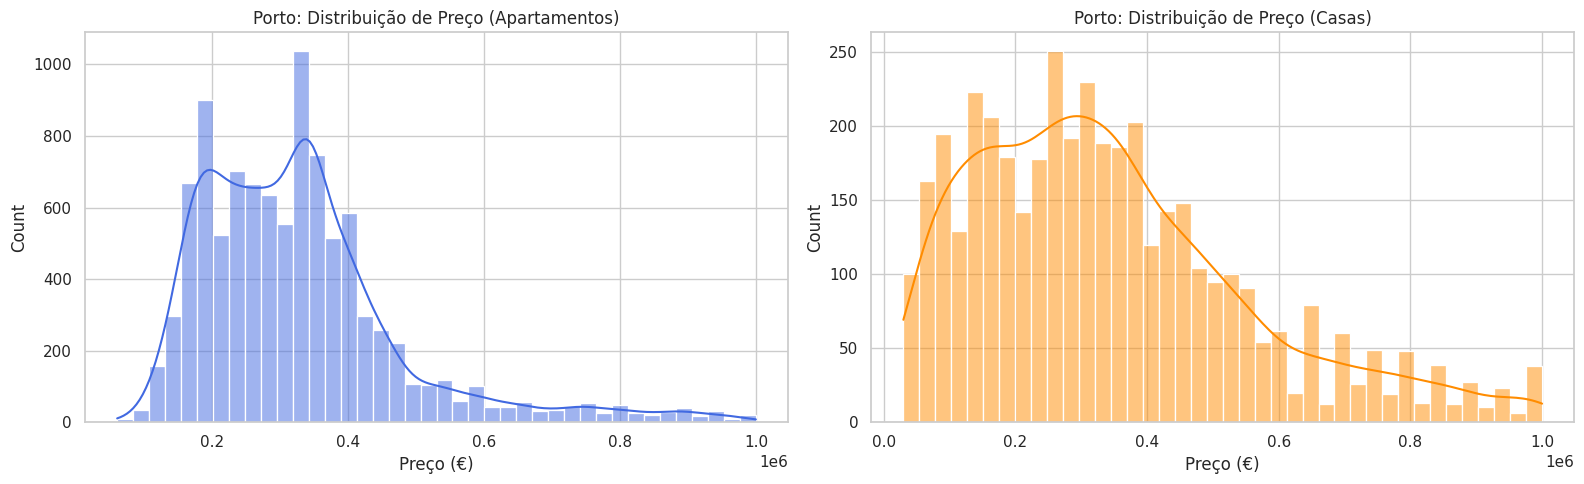

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico Apartamentos
sns.histplot(df_ap["Price"], bins=40, kde=True, ax=axes[0], color="royalblue")
axes[0].set_title("Porto: Distribuição de Preço (Apartamentos)")
axes[0].set_xlabel("Preço (€)")

# Gráfico Casas
sns.histplot(df_houses["Price"], bins=40, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Porto: Distribuição de Preço (Casas)")
axes[1].set_xlabel("Preço (€)")

plt.tight_layout()
plt.show()

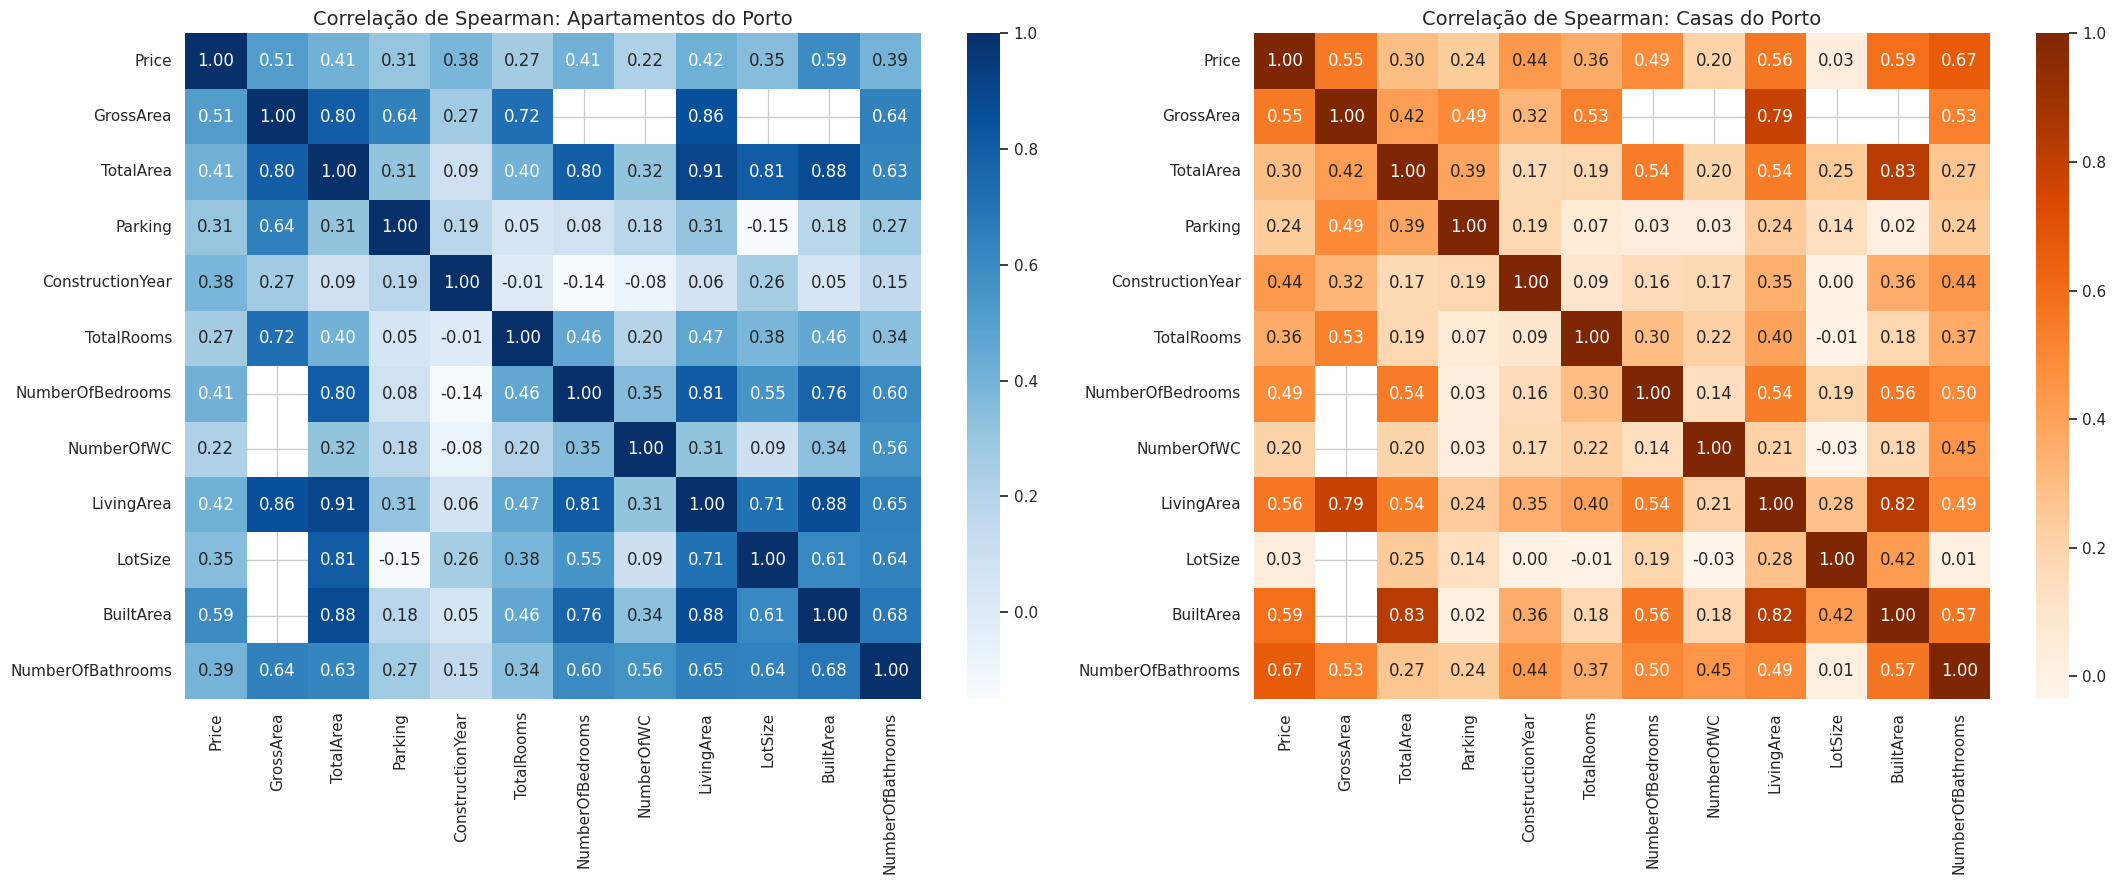

In [27]:
# Filtrar apenas colunas numéricas automaticamente
num_cols_ap = df_ap.select_dtypes(include=[np.number]).columns
num_cols_hs = df_houses.select_dtypes(include=[np.number]).columns

corr_ap = df_ap[num_cols_ap].corr(method="spearman")
corr_hs = df_houses[num_cols_hs].corr(method="spearman")

# Plotar as duas matrizes
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

sns.heatmap(corr_ap, annot=True, fmt=".2f", cmap="Blues", ax=axes[0], cbar=True)
axes[0].set_title("Correlação de Spearman: Apartamentos do Porto", fontsize=14)

sns.heatmap(corr_hs, annot=True, fmt=".2f", cmap="Oranges", ax=axes[1], cbar=True)
axes[1].set_title("Correlação de Spearman: Casas do Porto", fontsize=14)

plt.tight_layout()
plt.show()

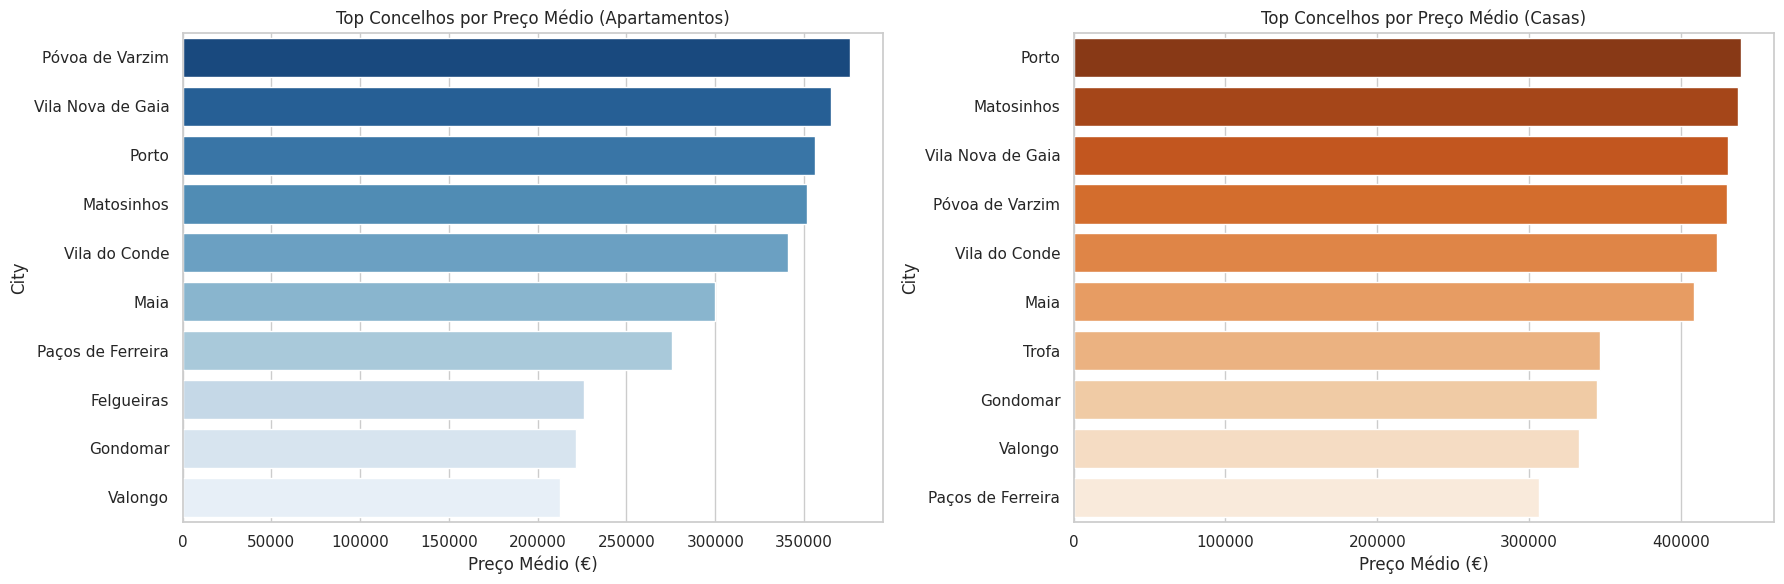

In [28]:
# Calcular médias por concelho
city_mean_ap = df_ap.groupby("City")["Price"].mean().sort_values(ascending=False).head(10)
city_mean_hs = df_houses.groupby("City")["Price"].mean().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))


sns.barplot(x=city_mean_ap.values, y=city_mean_ap.index, ax=axes[0], palette="Blues_r", hue=city_mean_ap.index, legend=False)
axes[0].set_title("Top Concelhos por Preço Médio (Apartamentos)")
axes[0].set_xlabel("Preço Médio (€)")

sns.barplot(x=city_mean_hs.values, y=city_mean_hs.index, ax=axes[1], palette="Oranges_r", hue=city_mean_hs.index, legend=False)
axes[1].set_title("Top Concelhos por Preço Médio (Casas)")
axes[1].set_xlabel("Preço Médio (€)")

plt.tight_layout()
plt.show()

## 2. Linear Regression Model

In [29]:
# 1. Carregar o dataset de apartamentos limpos do Porto
df_porto = pd.read_csv("../data/processed/porto_apartments_clean.csv")
print(f"Dataset carregado com sucesso. Dimensões: {df_porto.shape}")

# 2. Definir a variável alvo (y) e as variáveis preditoras (X)
target = "Price"
features = [
    "LivingArea", 
    "TotalArea", 
    "ConstructionYear", 
    "NumberOfBedrooms", 
    "NumberOfBathrooms", 
    "EnergyCertificate", 
    "Elevator", 
    "Parking", 
    "City", 
    "Town"
]

# Garantir que usamos apenas colunas que realmente existem no ficheiro
features = [f for f in features if f in df_porto.columns]

X_raw = df_porto[features].copy()
y = df_porto[target].copy()

Dataset carregado com sucesso. Dimensões: (9877, 25)


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [31]:
# Mapeamento das colunas por tipo
num_features = ["LivingArea", "TotalArea", "ConstructionYear", "NumberOfBedrooms", "NumberOfBathrooms", "Parking"]
cat_features = ["EnergyCertificate", "City", "Town"]
bin_features = ["Elevator"]

# Filtrar para bater certo com o nosso X_raw
num_features = [f for f in num_features if f in X_raw.columns]
cat_features = [f for f in cat_features if f in X_raw.columns]
bin_features = [f for f in bin_features if f in X_raw.columns]

# Configurar o tratamento para números (imputação pela mediana)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Configurar o tratamento para texto (One-Hot Encoding seguro)
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Juntar os tratamentos num único bloco transformador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features),
        ('bin', num_transformer, bin_features)
    ]
)

In [32]:
# 1. Separar os dados em conjuntos de Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)

# 2. Criar o pipeline final que junta o pré-processamento com o algoritmo matemático
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# 3. TREINAR O MODELO!
lr_model.fit(X_train, y_train)
print("Sucesso! O modelo de Regressão Linear está treinado e pronto.")

Sucesso! O modelo de Regressão Linear está treinado e pronto.


In [33]:
# Prever os preços para as casas de teste que o modelo nunca viu
y_pred = lr_model.predict(X_test)

# Calcular as métricas oficiais
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== MÉTRICAS DE AVALIAÇÃO (PORTO) ===")
print(f"Erro Médio Absoluto (MAE): {mae:,.2f} €")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:,.2f} €")
print(f"Coeficiente de Determinação (R²): {r2:.3f}")

=== MÉTRICAS DE AVALIAÇÃO (PORTO) ===
Erro Médio Absoluto (MAE): 64,133.77 €
Raiz do Erro Quadrático Médio (RMSE): 94,724.51 €
Coeficiente de Determinação (R²): 0.620


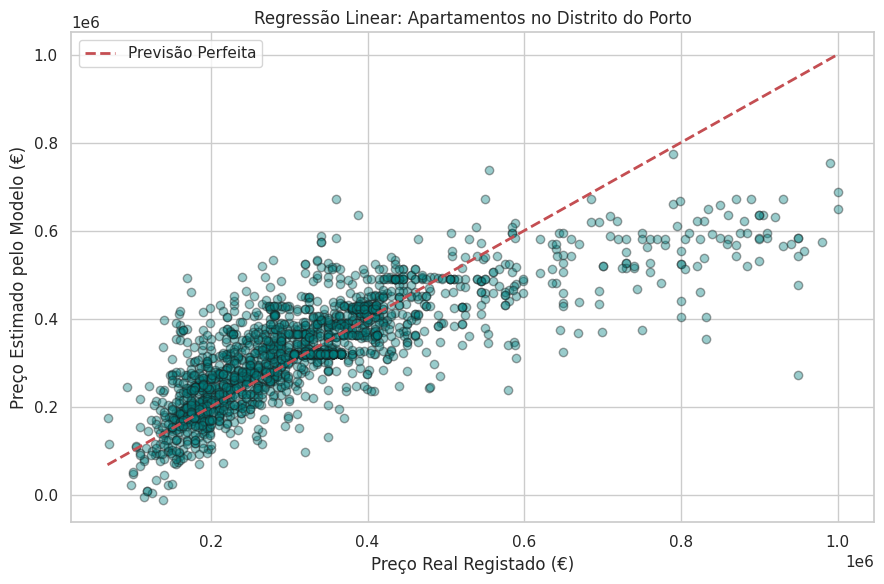

In [34]:
plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='teal', edgecolors='k')

# Desenhar a linha vermelha que representa a previsão perfeita (onde o real é igual ao previsto)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Previsão Perfeita")

plt.xlabel("Preço Real Registado (€)")
plt.ylabel("Preço Estimado pelo Modelo (€)")
plt.title("Regressão Linear: Apartamentos no Distrito do Porto")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Decision Tree and Random Forest

In [35]:
# Importar a Árvore de Decisão Regressora
from sklearn.tree import DecisionTreeRegressor

# Importar a Random Forest Regressora
from sklearn.ensemble import RandomForestRegressor

In [36]:
# 1. Criar o pipeline para a Árvore de Decisão
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42, max_depth=10)) # max_depth evita que a árvore cresça demais e decore os dados (overfitting)
])

# 2. Treinar o modelo
dt_pipeline.fit(X_train, y_train)

# 3. Prever e Avaliar
y_pred_dt = dt_pipeline.predict(X_test)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("=== Decision Tree ===")
print(f"MAE: {mae_dt:,.2f} €")
print(f"R²: {r2_dt:.3f}")

=== Decision Tree ===
MAE: 43,840.13 €
R²: 0.773


In [37]:
# 1. Criar o pipeline para a Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_split=5, random_state=42, n_jobs=-1)) # n_jobs=-1 usa todos os núcleos do seu processador para andar mais rápido
])

# 2. Treinar o modelo (pode demorar alguns segundos a mais porque gera 300 árvores)
rf_pipeline.fit(X_train, y_train)

# 3. Prever e Avaliar
y_pred_rf = rf_pipeline.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("=== Random Forest ===")
print(f"MAE: {mae_rf:,.2f} €")
print(f"R²: {r2_rf:.3f}")

=== Random Forest ===
MAE: 33,505.69 €
R²: 0.866


In [38]:
# Reúne as métricas calculadas (certifique-se de que correu a Regressão Linear antes)
tabela_resultados = pd.DataFrame({
    "Modelo": ["Regressão Linear", "Decision Tree", "Random Forest"],
    "MAE (€)": [mae, mae_dt, mae_rf], # 'mae' veio da célula da Regressão Linear
    "R² Score": [r2, r2_dt, r2_rf]
})

# Formatar a tabela para ficar mais legível
tabela_resultados["MAE (€)"] = tabela_resultados["MAE (€)"].map("{:,.2f} €".format)
tabela_resultados["R² Score"] = tabela_resultados["R² Score"].map("{:.3f}".format)

display(tabela_resultados)

,Modelo,MAE (€),R² Score
0,Regressão Linear,"64,133.77 €",0.620
1,Decision Tree,"43,840.13 €",0.773
2,Random Forest,"33,505.69 €",0.866


## 4. Creation of .pkl file

In [39]:
import joblib
import os

# Criar a pasta onde vamos guardar os modelos, caso ainda não exista
os.makedirs("../models", exist_ok=True)

In [40]:
# Definir o caminho de destino do ficheiro binário
apartments_model_path = "../models/porto_apartments_rf_model.pkl"

# Guardar o pipeline completo (inclui o pré-processador One-Hot Encoding + o algoritmo matemático)
joblib.dump(rf_pipeline, apartments_model_path)

print(f"Sucesso! Modelo de APARTAMENTOS exportado para: {apartments_model_path}")

Sucesso! Modelo de APARTAMENTOS exportado para: ../models/porto_apartments_rf_model.pkl


In [41]:
# 1. Carregar os dados das Casas
df_casas = pd.read_csv("../data/processed/porto_houses_clean.csv")

# 2. Separar as features e o alvo (garantindo colunas limpas para as casas)
features_casas = [f for f in features if f in df_casas.columns]
X_raw_casas = df_casas[features_casas].copy()
y_casas = df_casas[target].copy()

from sklearn.base import clone
preprocessor_casas = clone(preprocessor) 

# 3. Criar e treinar o pipeline das Casas com o seu próprio processador
rf_pipeline_casas = Pipeline(steps=[
    ('preprocessor', preprocessor_casas), 
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

rf_pipeline_casas.fit(X_raw_casas, y_casas)

# 4. Exportar o ficheiro binário das casas
houses_model_path = "../models/porto_houses_rf_model.pkl"
joblib.dump(rf_pipeline_casas, houses_model_path)

print(f"Sucesso! Modelo de CASAS exportado para: {houses_model_path}")

Sucesso! Modelo de CASAS exportado para: ../models/porto_houses_rf_model.pkl


## 5. Model Verification (Sanity Check)


In [42]:
import joblib
import pandas as pd

# 1. Carregar os modelos exportados para simular a aplicação
modelo_ap_carregado = joblib.load("../models/porto_apartments_rf_model.pkl")

# Cenário A: Apartamento minúsculo, antigo, sem extras (Esperamos um preço baixo)
pior_cenario = pd.DataFrame([{
    "LivingArea": 35, "TotalArea": 40, "ConstructionYear": 1970,
    "NumberOfBedrooms": 1, "NumberOfBathrooms": 1, "EnergyCertificate": "G",
    "Elevator": 0, "Parking": 0, "City": "Porto", "Town": "Bonfim"
}])

# Cenário B: Penthouse de Luxo enorme e nova (Esperamos um preço muito alto)
melhor_cenario = pd.DataFrame([{
    "LivingArea": 250, "TotalArea": 300, "ConstructionYear": 2025,
    "NumberOfBedrooms": 4, "NumberOfBathrooms": 4, "EnergyCertificate": "A+",
    "Elevator": 1, "Parking": 1, "City": "Porto", "Town": "Nevogilde"
}])

# Prever
preco_pior = modelo_ap_carregado.predict(pior_cenario)[0]
preco_melhor = modelo_ap_carregado.predict(melhor_cenario)[0]

print(f"=== TESTE DE SANIDADE (Apartamentos) ===")
print(f"Preço Estimado Pior Cenário: {preco_pior:,.2f} €")
print(f"Preço Estimado Melhor Cenário: {preco_melhor:,.2f} €")

# Validação automática
assert preco_melhor > preco_pior, "ERRO: O modelo está baralhado! O apartamento de luxo está mais barato que o antigo."
assert preco_pior > 0, "ERRO: O modelo está a prever valores negativos!"
print("-> Teste de Sanidade Espacial: PASSOu com sucesso!")

=== TESTE DE SANIDADE (Apartamentos) ===
Preço Estimado Pior Cenário: 157,875.33 €
Preço Estimado Melhor Cenário: 782,533.10 €
-> Teste de Sanidade Espacial: PASSOu com sucesso!


In [43]:
# 1. Pegar nas primeiras 5 linhas do conjunto de teste original (que o notebook usou)
amostra_X = X_test.head(5)
amostra_y_real = y_test.head(5).values

# 2. Prever usando o modelo que ainda está na memória do Notebook
pred_memoria = rf_pipeline.predict(amostra_X)

# 3. Prever usando o modelo que acabou de ser carregado do ficheiro .pkl
pred_pkl = modelo_ap_carregado.predict(amostra_X)

# 4. Comparar os dois vetores
diferenca_total = sum(abs(pred_memoria - pred_pkl))

print(f"\n=== TESTE DE CONSISTÊNCIA DO FICHEIRO ===")
print(f"Previsões em Memória: {pred_memoria.round(2)}")
print(f"Previsões do .PKL:     {pred_pkl.round(2)}")
print(f"Diferença acumulada:  {diferenca_total} €")

if diferenca_total == 0:
    print("-> Teste de Fidelidade de Dados: PASSOU! O ficheiro binário é 100% fiel ao original.")
else:
    print("-> AVISO: O ficheiro .pkl está a divergir do modelo original!")


=== TESTE DE CONSISTÊNCIA DO FICHEIRO ===
Previsões em Memória: [180900.66 282023.73 217400.72 233586.79 342422.49]
Previsões do .PKL:     [180900.66 282023.73 217400.72 233586.79 342422.49]
Diferença acumulada:  1.7462298274040222e-10 €
-> AVISO: O ficheiro .pkl está a divergir do modelo original!


In [44]:
# Aceder ao pré-processador que está guardado dentro do ficheiro .pkl
encoder_guardado = modelo_ap_carregado.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']

# Extrair os nomes das categorias categóricas que o modelo aprendeu a mapear
freguesias_aprendidas = encoder_guardado.categories_[2] # O índice 2 corresponde à coluna 'Town'

print(f"\n=== VERIFICAÇÃO DE METADADOS ===")
print(f"Total de Freguesias/Zonas mapeadas dentro do .pkl: {len(freguesias_aprendidas)}")
print(f"Exemplos de freguesias trancadas no modelo: {list(freguesias_aprendidas[:5])}...")

if len(freguesias_aprendidas) > 1:
    print("-> Teste de Engenharia de Atributos: PASSOU! As localizações geográficas foram serializadas corretamente.")


=== VERIFICAÇÃO DE METADADOS ===
Total de Freguesias/Zonas mapeadas dentro do .pkl: 137
Exemplos de freguesias trancadas no modelo: ['Abragão', 'Airães', 'Aldoar, Foz do Douro e Nevogilde', 'Alfena', 'Alpendorada, Várzea e Torrão']...
-> Teste de Engenharia de Atributos: PASSOU! As localizações geográficas foram serializadas corretamente.
